# PROJET MLOps COMPLET  -  Classification patients (malade / sain)

* logging **PostgreSQL integre des le depart** (plus de CSV ephemere pour les predictions)
* hebergement du modele **.pkl sur GitHub** pour permettre le reentrainement 

Pipeline de bout en bout : donnees -> exploration -> code propre (src/) -> API -> Docker -> tests -> CI/CD -> deploiement Render -> reentrainement automatique.


# PROJET MLOps COMPLET  -  Classification patients (malade / sain)

Version a DEUX FRONTS + boucle de reentrainement sur la VERITE.

Trois idees cles :
* logging **PostgreSQL** : chaque prediction laisse une trace permanente
* hebergement du **.pkl sur GitHub** (Option A) : le modele voyage dans git
* **2 fronts** separes : un pour predire (public), un pour confirmer le vrai diagnostic (medecin)

```
FRONT 1 (public)   -> /predict   -> table predictions            (SUPPOSITIONS du modele)
FRONT 2 (medecin)  -> /confirmer -> table diagnostics_confirmes   (VERITE)
                                          |
                                          v
retrain.py lit diagnostics_confirmes -> reentraine -> nouveau .pkl -> commit -> Render redeploie
```

Regle d'or : on ne reentraine JAMAIS sur les predictions (le modele apprendrait sur ses propres suppositions). On reentraine sur la verite confirmee.


## Vue d'ensemble  -  le fil logique

```
1. SETUP        environnement (venv, dossiers, librairies, base)
2. EXPLORATION  comprendre les donnees (brouillon jetable)
3. DECISIONS    figer les choix (colonnes, imputation, encodage)
4. CODE src/    modules propres et testables
5. BASE         2 tables : predictions (suppositions) + diagnostics_confirmes (verite)
6. API          /predict + /confirmer
7. FRONTS       page publique (predire) + page medecin (confirmer)
8. DOCKER        boite reproductible
9. TESTS + CI    verification auto a chaque push
10. DEPLOIEMENT  Render (base -> API -> fronts)
11. BOUCLE       retrain lit la verite -> nouveau .pkl commit sur GitHub -> redeploiement
```


## Les 2 tables  -  ne pas les confondre

```
table predictions              table diagnostics_confirmes
------------------             ---------------------------
qui ecrit  : l'API a chaque    qui ecrit  : le medecin via /confirmer
             /predict                       (+ le CSV de depart au seed)
contenu    : la classe PREDITE contenu    : le vrai malade (0/1)
role       : monitoring, trace role       : source d'entrainement
sert a     : suivre l'usage    sert a     : reentrainer le modele
```

Pourquoi deux tables ?
```
une prediction = ce que le modele SUPPOSE  -> ne peut pas servir a apprendre
un diagnostic  = ce qui est VRAI            -> sert a apprendre
Melanger les deux = le modele apprend ses propres erreurs (dangereux).
```


## Les 3 flux a garder en tete

Flux CI / CD (ton seul geste = git push) :
```
git push
   |
   v
CI  = GitHub lance pytest   -> vert = OK / rouge = STOP
   |  (si vert)
   v
CD  = Render prend le code, construit Docker, met l'API en ligne
```

Flux front / back (2 adresses separees sur Render) :
```
TA PAGE (front)  --appelle-->  TON API (back)
patients-front                 classification-patients
.onrender.com                  .onrender.com
```
* La page (Static Site) ne dort jamais.
* L'API (Web Service, plan gratuit) s'endort apres 15 min -> 1er appel ~30s de reveil.

Flux MLOps complet (la boucle) :
```
prediction via l'API
   |
   v
logger.py -> ecrit dans PostgreSQL (permanent)
   |
   v (chaque semaine, Cron Job)
retrain.py -> lit la base -> reentraine -> nouveau best_classifier.pkl
   |
   v
git commit + push du .pkl  ->  Render redeploie  ->  modele a jour en ligne
```


## Structure finale des fichiers

```
patients/
|-- venv/                    <- jamais sur GitHub
|-- mlflow.db                <- base MLflow locale (SQLite)
|-- local.db                 <- base predictions en LOCAL (SQLite, remplace PostgreSQL)
|-- data/patients.csv        <- 100 patients (donnees de depart)
|-- notebooks/exploration.ipynb
|-- models/best_classifier.pkl   <- MODELE : versionne sur GitHub (Option A)
|-- logs/
|-- src/
|   |-- __init__.py
|   |-- config.py            <- constantes + DATABASE_URL
|   |-- data.py              <- chargement + split
|   |-- preprocessing.py     <- imputation + encodage
|   |-- train.py             <- entraine + MLflow + sauvegarde .pkl
|   |-- predict.py           <- charge .pkl + predit
|   |-- logger.py            <- logging + ecriture PostgreSQL
|   |-- retrain.py           <- lit la base -> reentraine
|-- api/
|   |-- __init__.py
|   |-- main.py              <- API FastAPI
|-- tests/
|   |-- __init__.py
|   |-- test_api.py          <- pytest
|-- frontend/index.html      <- page web
|-- .github/workflows/
|   |-- ci.yml               <- tests a chaque push
|   |-- retrain.yml          <- reentrainement + commit du .pkl
|-- check_db.py              <- inspecter la base
|-- Dockerfile
|-- .dockerignore
|-- .gitignore               <- IMPORTANT : NE PAS ignorer models/*.pkl
|-- requirements.txt
```

Difference cle avec un projet debutant : le `.pkl` est **volontairement versionne** dans git (Option A), et les predictions vont en **base PostgreSQL** au lieu d'un CSV.


## Structure finale des fichiers

```
patients/
|-- data/patients.csv
|-- notebooks/exploration.ipynb
|-- models/best_classifier.pkl       <- versionne sur GitHub (Option A)
|-- logs/
|-- src/
|   |-- __init__.py
|   |-- config.py
|   |-- data.py
|   |-- preprocessing.py
|   |-- train.py
|   |-- predict.py
|   |-- logger.py            <- ecrit dans predictions
|   |-- confirm.py           <- ecrit dans diagnostics_confirmes
|   |-- retrain.py           <- lit diagnostics_confirmes
|-- api/
|   |-- __init__.py
|   |-- main.py              <- /predict + /confirmer
|-- tests/
|   |-- __init__.py
|   |-- test_api.py
|-- frontend/
|   |-- index.html           <- FRONT 1 (public, predire)
|   |-- confirm.html         <- FRONT 2 (medecin, confirmer)
|-- .github/workflows/
|   |-- ci.yml
|   |-- retrain.yml
|-- seed_db.py               <- amorcage de la table verite (1 fois)
|-- check_db.py
|-- Dockerfile
|-- .dockerignore
|-- .gitignore
|-- requirements.txt
```


## Objectif de chaque fichier

```
data/patients.csv     donnees de depart (100 patients) -> amorce la table verite
src/config.py         constantes + DATABASE_URL (SQLite local / PostgreSQL en ligne)
src/data.py           charger le CSV + split train/test
src/preprocessing.py  imputation (moyenne/mediane) + encodage
src/train.py          entrainer + comparer + MLflow + sauver best_classifier.pkl
src/predict.py        charger le .pkl + predire un patient
src/logger.py         ecrire chaque prediction dans la table predictions
src/confirm.py        ecrire un diagnostic confirme dans diagnostics_confirmes
src/retrain.py        lire diagnostics_confirmes -> reentrainer -> nouveau .pkl
seed_db.py            verser le CSV dans diagnostics_confirmes UNE fois (amorcage)
check_db.py           inspecter les 2 tables
api/main.py           API : /health, /predict, /confirmer
frontend/index.html   FRONT 1 public : formulaire de prediction
frontend/confirm.html FRONT 2 medecin : formulaire de diagnostic confirme
tests/test_api.py     tests pytest
Dockerfile            recette de la boite
.gitignore            NE PAS ignorer models/*.pkl (Option A)
```


# ====== PARTIE 1  -  SETUP ======

## 1.1  Projet + environnement virtuel

Le venv isole les librairies du projet. A activer a CHAQUE terminal (`(venv)` doit apparaitre).
VS Code : Ctrl+Shift+P -> "Python: Select Interpreter" -> choisir le venv.


In [ ]:
# Terminal (PowerShell)  -  decommente pour executer
# mkdir patients ; cd patients
# python -m venv venv
# .\\venv\\Scripts\\Activate.ps1
# python -c "import sys; print(sys.executable)"   # doit contenir 'venv'

# Creer les dossiers
# mkdir data, src, notebooks, models, logs, api, tests, frontend
# New-Item src/__init__.py
# New-Item api/__init__.py
# New-Item tests/__init__.py
'''data/       le CSV de depart + rien d'autre de versionne
src/        le code metier (config, data, prep, train, predict, logger, retrain)
notebooks/  l'exploration jetable (brouillon)
models/     le best_classifier.pkl (versionne sur GitHub, Option A)
logs/       les fichiers de log
api/        l'API FastAPI (main.py)
tests/      les tests pytest
frontend/   la page web (index.html)'''


## 1.2  Installer les librairies

On installe TOUT ce dont on aura besoin, y compris les 2 librairies base de donnees des le depart (`sqlalchemy` + `psycopg2-binary`), pour que le logging PostgreSQL soit pret immediatement.

Note : le paquet s'appelle **scikit-learn**, jamais `sklearn` (ce dernier est deprecie et fait echouer l'installation).


In [ ]:
# Librairies exploration + ML
# pip install pandas numpy scikit-learn matplotlib seaborn jupyter ipykernel

# Librairies API + tracking + tests
# pip install fastapi uvicorn mlflow joblib pytest httpx

# Librairies BASE DE DONNEES (des le depart)
# pip install sqlalchemy psycopg2-binary
#   sqlalchemy      = parle a la base en Python simple (SQLite en local, PostgreSQL en ligne)
#   psycopg2-binary = pilote PostgreSQL


In [2]:
pip install pandas numpy scikit-learn matplotlib seaborn jupyter ipykernel

  Using cached pandas-3.0.5-cp313-cp313-win_amd64.whl.metadata (19 kB)
  Using cached numpy-2.5.1-cp313-cp313-win_amd64.whl.metadata (6.6 kB)
  Using cached scikit_learn-1.9.0-cp313-cp313-win_amd64.whl.metadata (11 kB)
  Using cached matplotlib-3.11.1-cp313-cp313-win_amd64.whl.metadata (80 kB)
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached jupyter-1.1.1-py2.py3-none-any.whl.metadata (2.0 kB)
  Using cached tzdata-2026.3-py2.py3-none-any.whl.metadata (1.4 kB)
  Using cached scipy-1.18.0-cp313-cp313-win_amd64.whl.metadata (61 kB)
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached narwhals-2.24.0-py3-none-any.whl.metadata (15 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
  Using cached contourpy-1.3.3-cp313-cp313-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.63.0-cp313-cp313-win_amd64.whl.metadata (121 kB)
  Using cached kiwiso

ERROR: Could not install packages due to an OSError: [Errno 2] No such file or directory: 'c:\\Users\\segma\\Desktop\\IA\\1 PROJETS\\CLASSIFICATION\\MLOPS\\venv\\share\\jupyter\\labextensions\\@jupyter-widgets\\jupyterlab-manager\\static\\vendors-node_modules_d3-color_src_color_js-node_modules_d3-format_src_defaultLocale_js-node_m-09b215.2643c43f22ad111f4f82.js.map'
HINT: This error might have occurred since this system does not have Windows Long Path support enabled. You can find information on how to enable this at https://pip.pypa.io/warnings/enable-long-paths


[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
pip install fastapi uvicorn mlflow joblib pytest httpx

  Using cached fastapi-0.140.0-py3-none-any.whl.metadata (27 kB)
  Using cached uvicorn-0.51.0-py3-none-any.whl.metadata (6.6 kB)
  Using cached mlflow-3.14.0-py3-none-any.whl.metadata (49 kB)
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached pytest-9.1.1-py3-none-any.whl.metadata (7.6 kB)
  Using cached httpx-0.28.1-py3-none-any.whl.metadata (7.1 kB)
  Using cached starlette-1.3.1-py3-none-any.whl.metadata (6.4 kB)
  Using cached pydantic-2.13.4-py3-none-any.whl.metadata (109 kB)
  Using cached typing_inspection-0.4.2-py3-none-any.whl.metadata (2.6 kB)
  Using cached annotated_doc-0.0.4-py3-none-any.whl.metadata (6.6 kB)
  Using cached click-8.4.2-py3-none-any.whl.metadata (2.6 kB)
  Using cached h11-0.16.0-py3-none-any.whl.metadata (8.3 kB)
  Using cached mlflow_skinny-3.14.0-py3-none-any.whl.metadata (50 kB)
  Using cached mlflow_tracing-3.14.0-py3-none-any.whl.metadata (19 kB)
  Using cached flask_cors-6.0.5-py3-none-any.whl.metadata (5.4 kB)
  Using cac

ERROR: Could not install packages due to an OSError: [WinError 32] The process cannot access the file because it is being used by another process: 'c:\\Users\\segma\\Desktop\\IA\\1 PROJETS\\CLASSIFICATION\\MLOPS\\venv\\Lib\\site-packages\\sklearn\\cluster\\tests\\test_dbscan.py'
Check the permissions.


[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


  Using cached fastapi-0.140.0-py3-none-any.whl.metadata (27 kB)
  Using cached uvicorn-0.51.0-py3-none-any.whl.metadata (6.6 kB)
  Using cached mlflow-3.14.0-py3-none-any.whl.metadata (49 kB)
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached pytest-9.1.1-py3-none-any.whl.metadata (7.6 kB)
  Using cached httpx-0.28.1-py3-none-any.whl.metadata (7.1 kB)
  Using cached starlette-1.3.1-py3-none-any.whl.metadata (6.4 kB)
  Using cached pydantic-2.13.4-py3-none-any.whl.metadata (109 kB)
  Using cached annotated_doc-0.0.4-py3-none-any.whl.metadata (6.6 kB)
  Using cached click-8.4.2-py3-none-any.whl.metadata (2.6 kB)
  Using cached h11-0.16.0-py3-none-any.whl.metadata (8.3 kB)
  Using cached mlflow_skinny-3.14.0-py3-none-any.whl.metadata (50 kB)
  Using cached mlflow_tracing-3.14.0-py3-none-any.whl.metadata (19 kB)
  Using cached flask_cors-6.0.5-py3-none-any.whl.metadata (5.4 kB)
  Using cached flask-3.1.3-py3-none-any.whl.metadata (3.2 kB)
  Using cached aiohttp-


[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
pip install sqlalchemy psycopg2-binary

  Using cached sqlalchemy-2.0.51-cp313-cp313-win_amd64.whl.metadata (9.8 kB)
  Using cached greenlet-3.5.4-cp313-cp313-win_amd64.whl.metadata (3.9 kB)
Using cached sqlalchemy-2.0.51-cp313-cp313-win_amd64.whl (2.1 MB)
   ---------------------------------------- 0.0/2.8 MB ? eta -:--:--
   ---------------------------------------- 2.8/2.8 MB 20.8 MB/s  0:00:00
Using cached greenlet-3.5.4-cp313-cp313-win_amd64.whl (247 kB)

   ---------------------------------------- 0/3 [psycopg2-binary]
   ---------------------------------------- 0/3 [psycopg2-binary]
   ------------- -------------------------- 1/3 [greenlet]
   ------------- -------------------------- 1/3 [greenlet]
   ------------- -------------------------- 1/3 [greenlet]
   ------------- -------------------------- 1/3 [greenlet]
   ------------- -------------------------- 1/3 [greenlet]
   ------------- -------------------------- 1/3 [greenlet]
   -------------------------- ------------- 2/3 [sqlalchemy]
   --------------------------


[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


## 1.3  requirements.txt

Le fichier qui liste les librairies a installer (utilise par Docker et la CI). On y met SEULEMENT ce dont l'API a besoin en production (pas matplotlib/jupyter).

```
pandas
numpy
scikit-learn
joblib
mlflow
fastapi
uvicorn
sqlalchemy
psycopg2-binary
```


# ====== PARTIE 2  -  EXPLORATION (le brouillon) ======

On explore, on valide, PUIS on refactorise dans src/. Ce notebook est jetable : sa seule sortie utile, ce sont les DECISIONS (partie 3).

Le CSV doit etre dans `data/`.


## 2.1  Definition des colonnes

| Colonne | Role |
|---|---|
| `id_patient` | identifiant (supprime avant modele) |
| `date_naissance` | redondante avec age (corr ~ -1) -> supprimee |
| `age` | 8 NaN -> imputes par MOYENNE (variance faible) |
| `salaire` | 10 NaN -> imputes par MEDIANE (variance forte) |
| `conso_produit_x` | driver de la maladie |
| `conso_produit_y` | driver de la maladie |
| `niveau_vie` | categoriel (bas/moyen/eleve) -> encode |
| `malade` | CIBLE : 10 malades / 90 sains |


### 2.2  Chargement et inspection

In [1]:
import pandas as pd

df = pd.read_csv("data/patients.csv")
df.head()

,id_patient,date_naissance,age,salaire,conso_produit_x,conso_produit_y,niveau_vie,malade
0,1,1978-11-08,46.0,77561.0,5.1,5.3,eleve,0
1,2,1982-11-17,42.0,25972.0,3.4,4.0,moyen,0
2,3,1988-07-24,36.0,36892.0,6.1,10.1,moyen,0
3,4,1968-11-18,56.0,34972.0,2.1,7.8,moyen,0
4,5,1975-10-13,49.0,67894.0,0.7,5.6,eleve,0


In [7]:
df.info()              # types + non-nuls


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id_patient       100 non-null    int64  
 1   date_naissance   100 non-null    object 
 2   age              92 non-null     float64
 3   salaire          90 non-null     float64
 4   conso_produit_x  100 non-null    float64
 5   conso_produit_y  100 non-null    float64
 6   niveau_vie       100 non-null    object 
 7   malade           100 non-null    int64  
dtypes: float64(4), int64(2), object(2)
memory usage: 6.4+ KB


In [8]:
df.isna().sum()        # valeurs manquantes (age et salaire en ont)


id_patient          0
date_naissance      0
age                 8
salaire            10
conso_produit_x     0
conso_produit_y     0
niveau_vie          0
malade              0
dtype: int64

In [9]:
df.duplicated().sum()  # doublons


np.int64(0)

In [10]:
df.describe()          # stats descriptives


,id_patient,age,salaire,conso_produit_x,conso_produit_y,malade
count,100.000000,92.000000,90.000000,100.000000,100.00000,100.000000
mean,50.500000,48.271739,39947.666667,4.147000,4.16500,0.100000
std,29.011492,10.645231,23570.274792,2.173879,2.11867,0.301511
min,1.000000,27.000000,15677.000000,0.000000,0.00000,0.000000
25%,25.750000,40.750000,26990.000000,2.600000,2.60000,0.000000
50%,50.500000,47.000000,35032.500000,4.250000,3.95000,0.000000
75%,75.250000,56.250000,44156.750000,5.700000,5.52500,0.000000
max,100.000000,74.000000,175198.000000,11.100000,10.10000,1.000000


### 2.3  Equilibre des classes (desequilibre 90/10)

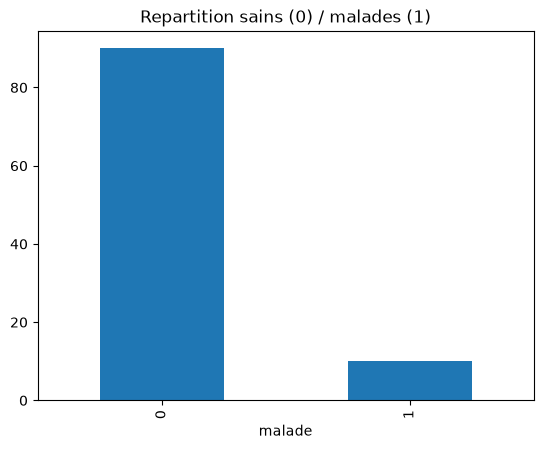

malade
0    0.9
1    0.1
Name: proportion, dtype: float64


In [11]:
import matplotlib.pyplot as plt

df["malade"].value_counts().plot(kind="bar")
plt.title("Repartition sains (0) / malades (1)")
plt.show()
print(df["malade"].value_counts(normalize=True))
# 90% sains, 10% malades -> l'accuracy seule sera trompeuse.
# On visera F1 / recall, et class_weight="balanced" dans les modeles.


### 2.4  Distributions et outliers

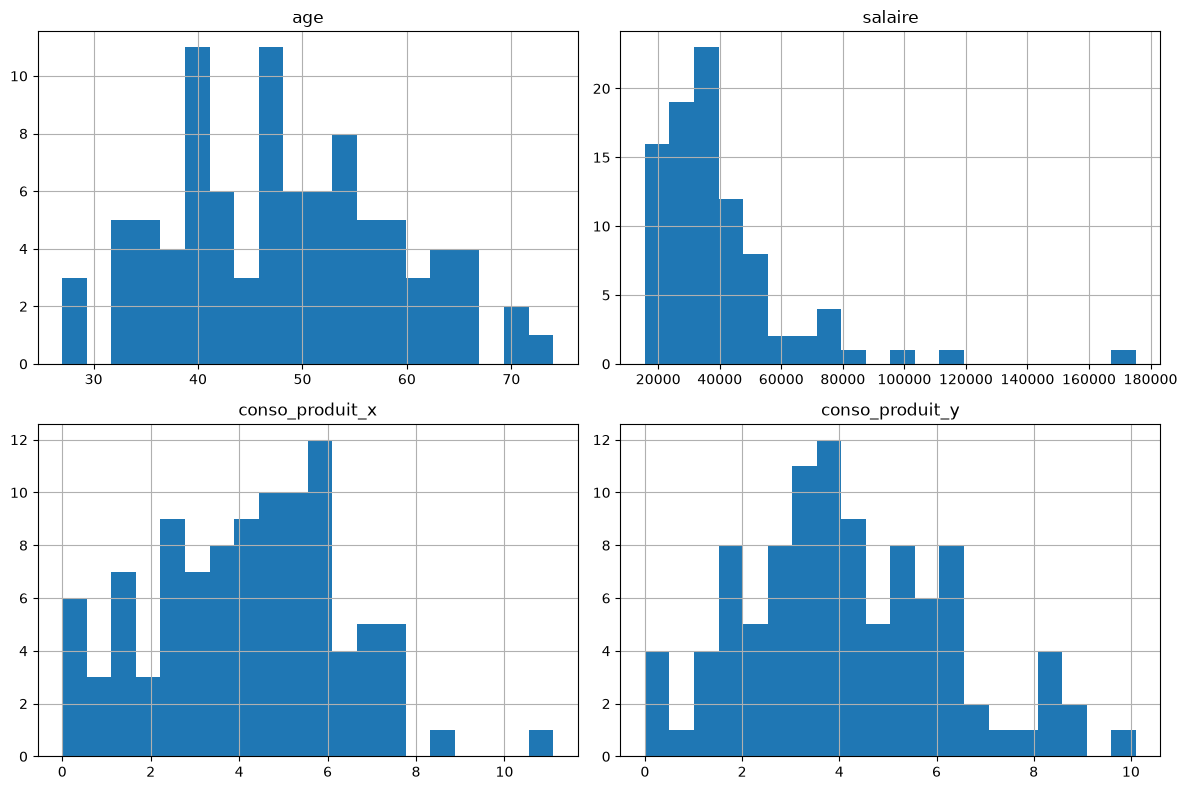

In [12]:
df[["age", "salaire", "conso_produit_x", "conso_produit_y"]].hist(figsize=(12, 8), bins=20)
plt.tight_layout()
plt.show()


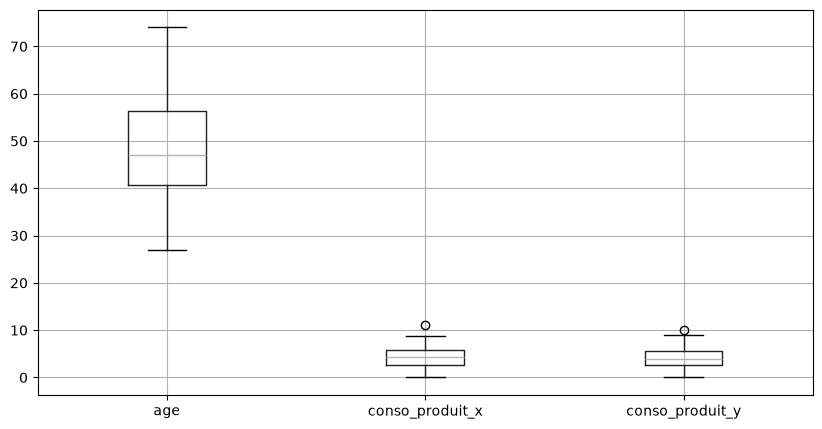

In [13]:
df[["age", "conso_produit_x", "conso_produit_y"]].boxplot(figsize=(10, 5))
plt.show()
# salaire a des outliers marques -> variance forte -> imputation par MEDIANE.


### 2.5  Signal des features (chevauchement = erreurs attendues)

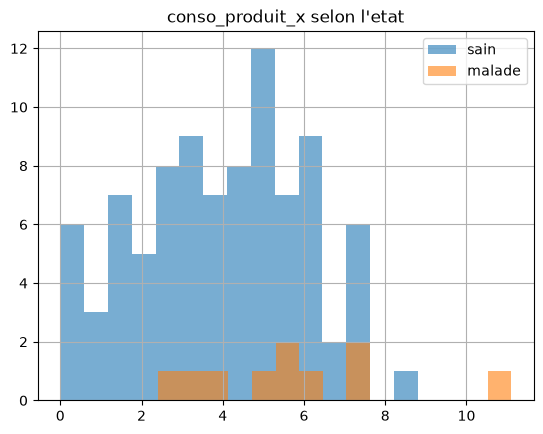

In [14]:
df[df["malade"] == 0]["conso_produit_x"].hist(alpha=0.6, label="sain", bins=15)
df[df["malade"] == 1]["conso_produit_x"].hist(alpha=0.6, label="malade", bins=15)
plt.legend(); plt.title("conso_produit_x selon l'etat")
plt.show()
# Les distributions se chevauchent -> le modele fera forcement des erreurs.


### 2.6  Correlation age <-> date_naissance ~ -1 (justifie la suppression)

In [16]:
pip install seaborn

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


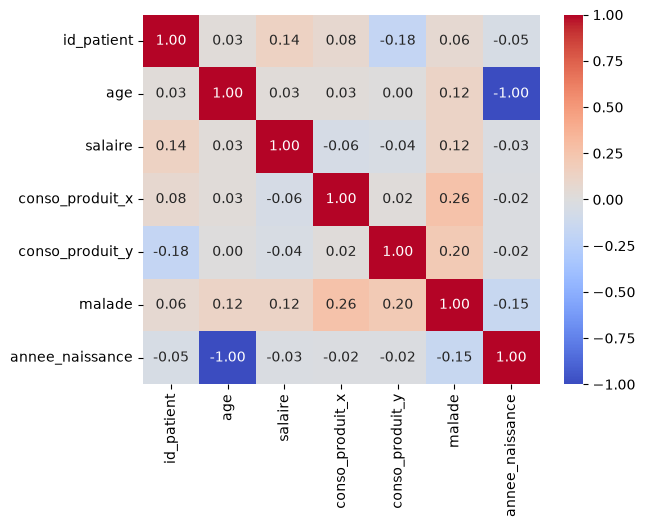

In [17]:
import seaborn as sns

df["annee_naissance"] = pd.to_datetime(df["date_naissance"]).dt.year
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm", fmt=".2f")
plt.show()
# age et annee_naissance sont quasi parfaitement correles -> on garde age, on drop date_naissance.


## 2.7  Conclusions de l'EDA  (ce qu'on FIGE)

Ces decisions deviennent les constantes de `src/config.py` :

* drop `id_patient` (inutile) et `date_naissance` (redondante avec age)
* imputer `age` par la MOYENNE, `salaire` par la MEDIANE
* encoder `niveau_vie` (OneHot)
* garder `conso_produit_x`, `conso_produit_y` telles quelles
* cible = `malade`, desequilibre 90/10 -> `class_weight="balanced"`, metrique = F1 / recall
* split stratifie 80/20


### 2.8  Verifier le split stratifie et le preprocessing (test rapide)

In [18]:
from sklearn.model_selection import train_test_split

data = df.drop(columns=["id_patient", "date_naissance", "annee_naissance"])
X = data.drop(columns="malade")
y = data["malade"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42)
print("Train:", X_train.shape, "| malades:", int(y_train.sum()))
print("Test :", X_test.shape, "| malades:", int(y_test.sum()))


Train: (80, 5) | malades: 8
Test : (20, 5) | malades: 2


In [19]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

prep = ColumnTransformer([
    ("mean",   SimpleImputer(strategy="mean"),   ["age"]),
    ("median", SimpleImputer(strategy="median"), ["salaire"]),
    ("cat",    OneHotEncoder(handle_unknown="ignore"), ["niveau_vie"]),
    ("keep",   "passthrough", ["conso_produit_x", "conso_produit_y"]),
])
Xp = prep.fit_transform(X_train)
print("Shape avant:", X_train.shape, "-> apres:", Xp.shape)   # (80,5) -> (80,7)


Shape avant: (80, 5) -> apres: (80, 7)


### 2.9  Comparer 2 modeles (baseline)

In [20]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score, classification_report, ConfusionMatrixDisplay

modeles = {
    "logreg": LogisticRegression(class_weight="balanced", max_iter=1000, random_state=42),
    "random_forest": RandomForestClassifier(max_depth=2, n_estimators=25,
                        class_weight="balanced", random_state=42),
}
for nom, clf in modeles.items():
    pipe = Pipeline([("prep", prep), ("clf", clf)])
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    print(f"{nom:15} F1 = {f1_score(y_test, y_pred, zero_division=0):.3f}")


logreg          F1 = 0.286
random_forest   F1 = 0.400


> Une fois l'exploration validee, on ARRETE de coder dans le notebook.
> On recopie ces choix, proprement, dans `src/`. C'est la partie 3.


# ====== PARTIE 3  -  CODE PROPRE (src/) ======

Chaque fichier a UN role et son propre test. On construit dans l'ordre des dependances :
`config -> data -> preprocessing -> train -> predict -> logger -> retrain`.

Nouveaute importante : `config.py` contient DES LE DEPART `DATABASE_URL`, et `logger.py` ecrit en base (pas en CSV).


## 3.1  src/config.py  -  le socle (constantes + base de donnees)

Contient : SEED, chemins, colonnes, URI MLflow, et surtout `DATABASE_URL`.

Idee cle du `DATABASE_URL` :
```
en LOCAL  -> variable absente -> SQLite (fichier local.db)
en LIGNE  -> Render fournit DATABASE_URL -> PostgreSQL
        => MEME CODE, deux environnements
```

Test : `python -c "from src import config; print(config.RAW_DATA); print('DB =', config.DATABASE_URL)"`


In [ ]:
# CONTENU de src/config.py

from pathlib import Path                    # chemins de fichiers propres
import os                                   # lire la variable d'environnement DATABASE_URL

# --- Reproductibilite ---
SEED = 42                                   # fixe le hasard -> memes resultats

# --- Dossiers ---
ROOT = Path(__file__).resolve().parent.parent   # racine du projet
DATA_DIR = ROOT / "data"
MODELS_DIR = ROOT / "models"
LOGS_DIR = ROOT / "logs"

# --- Fichiers ---
RAW_DATA = DATA_DIR / "patients.csv"                # donnees de depart
MODEL_PATH = MODELS_DIR / "best_classifier.pkl"     # modele (versionne sur GitHub)

# --- Base de donnees ---
# En local : DATABASE_URL absente -> SQLite (fichier local.db).
# En ligne : Render injecte DATABASE_URL -> PostgreSQL permanent.
DATABASE_URL = os.getenv("DATABASE_URL", f"sqlite:///{ROOT / 'local.db'}")

# --- Colonnes (issues de l'exploration) ---
TARGET = "malade"                                   # cible (0=sain, 1=malade)
DROP_COLS = ["id_patient", "date_naissance"]        # supprimees
MEAN_IMPUTE_COLS = ["age"]                          # NaN -> moyenne
MEDIAN_IMPUTE_COLS = ["salaire"]                    # NaN -> mediane
CAT_COLS = ["niveau_vie"]                           # categoriel -> encode
PASSTHROUGH_COLS = ["conso_produit_x", "conso_produit_y"]  # gardees

# --- Parametres ---
TEST_SIZE = 0.2                             # 20% test / 80% train
MLFLOW_TRACKING_URI = f"sqlite:///{ROOT / 'mlflow.db'}"

# --- Cree les dossiers s'ils manquent ---
for d in (DATA_DIR, MODELS_DIR, LOGS_DIR):
    d.mkdir(exist_ok=True)


## 3.2  src/data.py  -  chargement + split

| Fonction | Role |
|---|---|
| `load_data(path)` | CSV -> DataFrame |
| `split_data(df)` | drop, X/y, split stratifie 80/20 |

Test : `python -m src.data` -> `(100, 8)` / Train `(80, 5)` / Test `(20, 5)`


In [ ]:
# CONTENU de src/data.py

import pandas as pd
from sklearn.model_selection import train_test_split
from src import config

def load_data(path=config.RAW_DATA):
    return pd.read_csv(path)                          # CSV -> DataFrame

def split_data(df):
    data = df.drop(columns=config.DROP_COLS)          # enleve id + date_naissance
    X = data.drop(columns=config.TARGET)              # features
    y = data[config.TARGET]                           # cible
    return train_test_split(X, y, test_size=config.TEST_SIZE,
                            stratify=y, random_state=config.SEED)   # split 80/20 stratifie

if __name__ == "__main__":                            # banc d'essai
    df = load_data()
    X_train, X_test, y_train, y_test = split_data(df)
    print("Train :", X_train.shape, "| Test :", X_test.shape)


## 3.3  src/preprocessing.py  -  imputation + encodage

`build_preprocessor()` -> ColumnTransformer (age->moyenne, salaire->mediane, niveau_vie->OneHot).
Non entraine ici (on evite le data leakage : le fit se fait dans le pipeline, sur le train seulement).

Test : `python -m src.preprocessing` -> shape (80,5) -> (80,7)


In [ ]:
# CONTENU de src/preprocessing.py

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from src import config

def build_preprocessor():
    mean_pipe   = Pipeline([("imputer", SimpleImputer(strategy="mean"))])    # age
    median_pipe = Pipeline([("imputer", SimpleImputer(strategy="median"))])  # salaire
    cat_pipe    = Pipeline([("encoder", OneHotEncoder(handle_unknown="ignore"))])  # niveau_vie

    return ColumnTransformer([
        ("mean",   mean_pipe,     config.MEAN_IMPUTE_COLS),
        ("median", median_pipe,   config.MEDIAN_IMPUTE_COLS),
        ("cat",    cat_pipe,      config.CAT_COLS),
        ("keep",   "passthrough", config.PASSTHROUGH_COLS),
    ])

if __name__ == "__main__":
    from src.data import load_data, split_data
    df = load_data()
    X_train, X_test, y_train, y_test = split_data(df)
    prep = build_preprocessor()
    Xp = prep.fit_transform(X_train)
    print("Shape avant :", X_train.shape, "-> apres :", Xp.shape)


## 3.4  src/train.py  -  entraine + compare + MLflow + sauvegarde .pkl
Objectif : entrainer 2 modeles, tracer avec MLflow, garder le meilleur -> best_classifier.pkl.

Nouveaute 2-fronts : `train()` accepte un DataFrame optionnel. Par defaut il lit le CSV, mais `retrain.py` lui passera les diagnostics confirmes de la base.

Test : `python -m src.train`
C'est ici que le fameux `best_classifier.pkl` est cree. Ce fichier sera **versionne sur GitHub** (Option A) pour que Render puisse le charger au deploiement.

Test : `python -m src.train` -> F1 des 2 modeles + meilleur + .pkl sauvegarde
MLflow : `mlflow ui --backend-store-uri sqlite:///mlflow.db` -> http://127.0.0.1:5000

> Bug connu : `serialization_format="cloudpickle"` evite l'erreur skops/numpy.dtype.


In [ ]:
# CONTENU de src/train.py

import joblib, mlflow, mlflow.sklearn
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score, precision_score, recall_score, accuracy_score
from sklearn.model_selection import train_test_split
from src import config
from src.data import load_data
from src.preprocessing import build_preprocessor

def get_models():
    # Les 2 candidats a comparer :
    return {
        "logreg": LogisticRegression(class_weight="balanced", max_iter=1000,
                                     random_state=config.SEED),
        "random_forest": RandomForestClassifier(max_depth=2, n_estimators=25,
                          class_weight="balanced", random_state=config.SEED),
    }

def evaluate(pipe, X_test, y_test):
    y_pred = pipe.predict(X_test)                     # predictions sur le test
    return {"accuracy":  accuracy_score(y_test, y_pred),
            "precision": precision_score(y_test, y_pred, zero_division=0),
            "recall":    recall_score(y_test, y_pred, zero_division=0),
            "f1":        f1_score(y_test, y_pred, zero_division=0)}

def train(df=None):
    # df=None -> on lit le CSV. Sinon on utilise le DataFrame fourni (ex: la base de verite).
    if df is None:
        df = load_data()
    data = df.drop(columns=[c for c in config.DROP_COLS if c in df.columns])  # enleve id/date si presents
    X = data.drop(columns=config.TARGET); y = data[config.TARGET]
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=config.TEST_SIZE, stratify=y, random_state=config.SEED)

    mlflow.set_tracking_uri(config.MLFLOW_TRACKING_URI)   # ou MLflow enregistre
    mlflow.set_experiment("classification_patients")

    resultats = {}
    for nom, clf in get_models().items():
        with mlflow.start_run(run_name=nom):              # un run MLflow par modele
            pipe = Pipeline([("preprocessing", build_preprocessor()), ("clf", clf)])
            pipe.fit(X_train, y_train)                    # entraine
            metrics = evaluate(pipe, X_test, y_test)      # evalue

            mlflow.log_param("model", nom)                # trace le nom
            mlflow.log_metrics(metrics)                   # trace les 4 metriques
            mlflow.sklearn.log_model(pipe, name="model",
                                     serialization_format="cloudpickle")  # evite bug skops/numpy

            resultats[nom] = {"pipeline": pipe, "f1": metrics["f1"]}
            print(f"{nom:15} | F1={metrics['f1']:.3f} | recall={metrics['recall']:.3f}")

    meilleur = max(resultats, key=lambda n: resultats[n]["f1"])   # F1 le plus haut
    joblib.dump(resultats[meilleur]["pipeline"], config.MODEL_PATH)  # sauve le .pkl
    print(f"Meilleur : {meilleur} -> sauvegarde {config.MODEL_PATH}")

if __name__ == "__main__":
    train()


## 3.5  src/predict.py  -  charge le .pkl + predit

Charge le modele une seule fois (mise en cache), puis predit pour un patient.

Test : `python -m src.predict` -> `{'classe':1,'label':'malade','proba_malade':0.71}`


In [ ]:
# CONTENU de src/predict.py

import joblib, pandas as pd
from src import config

_model = None                                  # cache : charge une seule fois

def load_model(path=config.MODEL_PATH):
    global _model
    if _model is None:
        _model = joblib.load(path)             # charge le .pkl depuis le disque
    return _model

def predict_one(patient: dict):
    model = load_model()
    X = pd.DataFrame([patient])                # 1 patient -> tableau 1 ligne
    classe = int(model.predict(X)[0])         # 0=sain, 1=malade
    proba = float(model.predict_proba(X)[0][1])   # probabilite d'etre malade
    return {"classe": classe,
            "label": "malade" if classe == 1 else "sain",
            "proba_malade": round(proba, 3)}

if __name__ == "__main__":
    p = {"age": 62, "salaire": 28000, "conso_produit_x": 9.5,
         "conso_produit_y": 8.0, "niveau_vie": "moyen"}
    print(predict_one(p))


## 3.6  src/logger.py  -  logging + ecriture PostgreSQL (integre des le depart)
Objectif : chaque prediction ecrit 1 ligne dans la table `predictions`. Sert au monitoring, PAS au reentrainement.
Test :
```bash
python -c "from src.logger import log_prediction; log_prediction({'age':60,'salaire':30000,'conso_produit_x':8,'conso_produit_y':7,'niveau_vie':'moyen'}, {'classe':1,'label':'malade','proba_malade':0.8}); print('OK')"
```
C'est le coeur de la version reorganisee : chaque prediction ecrit **une ligne dans la base** (SQLite en local, PostgreSQL en ligne), plus un message console. Fini le CSV ephemere.

```
1 prediction = 1 message console (INFO) + 1 ligne inseree en base (permanente)
```

Pourquoi une base et pas un CSV ?
```
CSV dans le conteneur Render = EPHEMERE (disparait a chaque redemarrage)
PostgreSQL = base PERMANENTE (hors conteneur) -> survit -> permet d'accumuler -> reentrainer
```

Test (local, SQLite) :
```bash
python -c "from src.logger import log_prediction; log_prediction({'age':60,'salaire':30000,'conso_produit_x':8,'conso_produit_y':7,'niveau_vie':'moyen'}, {'classe':1,'label':'malade','proba_malade':0.8}); print('OK')"
```


In [ ]:
# CONTENU de src/logger.py

import logging
from datetime import datetime
from sqlalchemy import create_engine, text     # create_engine=connexion | text=SQL
from src import config

# --- Logs console ---
logging.basicConfig(level=logging.INFO,
    format="%(asctime)s | %(levelname)s | %(message)s")
logger = logging.getLogger("patients_api")

# --- Connexion (SQLite local / PostgreSQL en ligne) ---
engine = create_engine(config.DATABASE_URL)

# --- Table des SUPPOSITIONS, creee si absente ---
with engine.begin() as conn:
    conn.execute(text(
        "CREATE TABLE IF NOT EXISTS predictions ("
        "id SERIAL PRIMARY KEY, timestamp TEXT, age FLOAT, salaire FLOAT, "
        "conso_produit_x FLOAT, conso_produit_y FLOAT, niveau_vie TEXT, "
        "classe INTEGER, label TEXT, proba_malade FLOAT)"))

INSERT_SQL = (                                  # requete d'insertion preparee
    "INSERT INTO predictions "
    "(timestamp, age, salaire, conso_produit_x, conso_produit_y, "
    "niveau_vie, classe, label, proba_malade) VALUES "
    "(:timestamp, :age, :salaire, :cx, :cy, :niveau_vie, :classe, :label, :proba)")

def log_prediction(patient: dict, resultat: dict):
    logger.info(f"PREDICTION | {patient} -> {resultat}")   # 1) console
    with engine.begin() as conn:                           # 2) 1 ligne en base
        conn.execute(text(INSERT_SQL), {
            "timestamp": datetime.now().isoformat(timespec="seconds"),
            "age": patient["age"], "salaire": patient["salaire"],
            "cx": patient["conso_produit_x"], "cy": patient["conso_produit_y"],
            "niveau_vie": patient["niveau_vie"],
            "classe": resultat["classe"], "label": resultat["label"],
            "proba": resultat["proba_malade"]})


In [ ]:
## 3.7  src/confirm.py  -  table diagnostics_confirmes (VERITE)
Objectif : le medecin confirme le VRAI diagnostic. Chaque confirmation ecrit 1 ligne dans `diagnostics_confirmes`. C'est CETTE table qui sert a reentrainer.
Test :
```bash
python -c "from src.confirm import confirm_diagnostic; confirm_diagnostic({'age':55,'salaire':22000,'conso_produit_x':9,'conso_produit_y':8,'niveau_vie':'bas','malade':1}); print('OK')"
```


In [ ]:
# CONTENU de src/confirm.py

import logging
from sqlalchemy import create_engine, text
from src import config

logger = logging.getLogger("patients_api")

engine = create_engine(config.DATABASE_URL)     # meme base que logger.py

# --- Table de la VERITE, creee si absente ---
# Memes colonnes que le CSV (apres drop) + malade = le VRAI diagnostic.
with engine.begin() as conn:
    conn.execute(text(
        "CREATE TABLE IF NOT EXISTS diagnostics_confirmes ("
        "id SERIAL PRIMARY KEY, age FLOAT, salaire FLOAT, "
        "conso_produit_x FLOAT, conso_produit_y FLOAT, "
        "niveau_vie TEXT, malade INTEGER)"))

INSERT_SQL = (
    "INSERT INTO diagnostics_confirmes "
    "(age, salaire, conso_produit_x, conso_produit_y, niveau_vie, malade) VALUES "
    "(:age, :salaire, :cx, :cy, :niveau_vie, :malade)")

def confirm_diagnostic(patient: dict):
    # patient DOIT contenir "malade" (0 ou 1) : c'est la verite fournie par le medecin.
    logger.info(f"CONFIRMATION | {patient}")
    with engine.begin() as conn:
        conn.execute(text(INSERT_SQL), {
            "age": patient["age"], "salaire": patient["salaire"],
            "cx": patient["conso_produit_x"], "cy": patient["conso_produit_y"],
            "niveau_vie": patient["niveau_vie"], "malade": patient["malade"]})


## 3.8  src/retrain.py  -  reentraine sur la VERITE
Objectif : lire `diagnostics_confirmes` (jamais `predictions`) et relancer l'entrainement dessus.

```
diagnostics_confirmes (verite)  ->  train(df)  ->  nouveau best_classifier.pkl
```
Test : `python -m src.retrain`

In [ ]:
# CONTENU de src/retrain.py

import pandas as pd
from sqlalchemy import create_engine
from src import config
from src.train import train

def charger_verite():
    # Lit UNIQUEMENT la table de verite (diagnostics confirmes par le medecin).
    engine = create_engine(config.DATABASE_URL)
    return pd.read_sql("SELECT * FROM diagnostics_confirmes", engine)

if __name__ == "__main__":
    df = charger_verite()
    print(f"{len(df)} diagnostics confirmes disponibles")
    if len(df) < 20:
        print("Trop peu de donnees pour reentrainer -> on garde le modele actuel")
    else:
        train(df.drop(columns=["id"]))    # enleve la cle technique, reentraine sur la verite
        print("Reentrainement termine -> nouveau best_classifier.pkl")


# ====== PARTIE 4  -  AMORCER LA BASE (seed_db.py) ======

Objectif : la table `diagnostics_confirmes` est VIDE au depart -> retrain n'aurait rien a lire. On y verse les 100 lignes du CSV **une seule fois**.

Le garde-fou `if deja == 0` empeche de reverser le CSV a chaque lancement (sinon 100, 200, 300... doublons).

Test : `python seed_db.py`


In [ ]:
# CONTENU de seed_db.py (a la racine)

import pandas as pd
from sqlalchemy import create_engine, text
from src import config

engine = create_engine(config.DATABASE_URL)

# --- Cree la table de verite si absente ---
with engine.begin() as conn:
    conn.execute(text(
        "CREATE TABLE IF NOT EXISTS diagnostics_confirmes ("
        "id SERIAL PRIMARY KEY, age FLOAT, salaire FLOAT, "
        "conso_produit_x FLOAT, conso_produit_y FLOAT, "
        "niveau_vie TEXT, malade INTEGER)"))
    # Compte les lignes deja presentes (le garde-fou)
    deja = conn.execute(text("SELECT COUNT(*) FROM diagnostics_confirmes")).scalar()

# --- On verse le CSV UNIQUEMENT si la table est vide ---
if deja == 0:
    df = pd.read_csv(config.RAW_DATA).drop(columns=config.DROP_COLS)  # memes colonnes que la table
    df.to_sql("diagnostics_confirmes", engine, if_exists="append", index=False)
    print(f"Seed : {len(df)} lignes du CSV inserees")
else:
    print(f"Deja {deja} lignes -> pas de seed (garde-fou)")   # evite les doublons


# ====== PARTIE 5  -  API FastAPI ======

Objectif : exposer 2 routes.
```
/predict    recoit un patient (sans malade)    -> predit + logge dans predictions
/confirmer  recoit un patient AVEC malade (0/1) -> ecrit dans diagnostics_confirmes
```
Lancer : `uvicorn api.main:app --reload` -> http://127.0.0.1:8000/docs


In [ ]:
# CONTENU de api/main.py

from fastapi import FastAPI
from fastapi.middleware.cors import CORSMiddleware   # autorise les pages web a appeler l'API
from pydantic import BaseModel                       # valide les donnees recues
from src.predict import predict_one
from src.logger import log_prediction                # -> table predictions
from src.confirm import confirm_diagnostic           # -> table diagnostics_confirmes

app = FastAPI(title="API Classification Patients")

app.add_middleware(CORSMiddleware, allow_origins=["*"],
                   allow_methods=["*"], allow_headers=["*"])

# --- Schema FRONT 1 : un patient a predire (PAS de malade) ---
class Patient(BaseModel):
    age: float
    salaire: float
    conso_produit_x: float
    conso_produit_y: float
    niveau_vie: str

# --- Schema FRONT 2 : un diagnostic confirme (AVEC malade) ---
class PatientConfirme(Patient):    # herite de Patient + ajoute le vrai diagnostic
    malade: int                    # 0 = sain, 1 = malade (verite)

@app.get("/health")                # verifier que l'API tourne
def health():
    return {"status": "ok"}

# --- FRONT 1 (public) : predire ---
@app.post("/predict")
def predict(patient: Patient):
    d = patient.model_dump()       # patient -> dict
    r = predict_one(d)             # prediction (dernier .pkl)
    log_prediction(d, r)           # trace dans predictions (supposition)
    return r

# --- FRONT 2 (medecin) : confirmer le vrai diagnostic ---
@app.post("/confirmer")
def confirmer(patient: PatientConfirme):
    d = patient.model_dump()       # contient malade (la verite)
    confirm_diagnostic(d)          # ecrit dans diagnostics_confirmes
    return {"status": "diagnostic enregistre", "malade": d["malade"]}


# ====== PARTIE 6  -  LES 2 FRONTS ======

## 6.1  FRONT 1  -  frontend/index.html (public, PREDIRE)
Objectif : formulaire sans le champ malade -> POST /predict -> affiche malade/sain.


In [ ]:
<!DOCTYPE html>
<html lang="fr">
<head>
  <meta charset="UTF-8">
  <meta name="viewport" content="width=device-width, initial-scale=1.0">
  <title>Prediction Patient</title>
  <style>
    body { font-family: system-ui, sans-serif; max-width: 460px; margin: 40px auto; padding: 0 20px; background: #f0f4f8; }
    .card { background: #fff; border-radius: 14px; padding: 26px; box-shadow: 0 4px 20px rgba(0,0,0,.08); }
    label { display: block; margin: 12px 0 4px; font-weight: 600; font-size: .9rem; }
    input, select { width: 100%; padding: 10px; border: 1px solid #cdd5df; border-radius: 8px; }
    button { margin-top: 20px; width: 100%; padding: 12px; background: #2563eb; color: #fff; border: none; border-radius: 8px; font-weight: 600; cursor: pointer; }
    #res { margin-top: 18px; padding: 16px; border-radius: 10px; text-align: center; display: none; }
    .malade { background: #fee2e2; color: #991b1b; } .sain { background: #dcfce7; color: #166534; }
  </style>
</head>
<body>
  <div class="card">
    <h2>Prediction (public)</h2>
    <label>Age</label><input type="number" id="age" value="62">
    <label>Salaire</label><input type="number" id="salaire" value="28000">
    <label>Conso produit X</label><input type="number" step="0.1" id="cx" value="9.5">
    <label>Conso produit Y</label><input type="number" step="0.1" id="cy" value="8.0">
    <label>Niveau de vie</label>
    <select id="niveau_vie"><option>bas</option><option selected>moyen</option><option>eleve</option></select>
    <button onclick="predire()">Predire</button>
    <div id="res"></div>
  </div>
  <script>
    const API_URL = "https://classification-patients.onrender.com";   // <- ton URL API
    async function predire() {
      // On assemble le patient SANS le champ malade (on ne le connait pas)
      const patient = {
        age: +age.value, salaire: +salaire.value,
        conso_produit_x: +cx.value, conso_produit_y: +cy.value,
        niveau_vie: niveau_vie.value,
      };
      const rep = await fetch(API_URL + "/predict", {           // appelle FRONT 1 -> /predict
        method: "POST", headers: { "Content-Type": "application/json" },
        body: JSON.stringify(patient),
      });
      const data = await rep.json();
      res.style.display = "block";
      res.className = data.label === "malade" ? "malade" : "sain";
      res.innerHTML = `<b>${data.label.toUpperCase()}</b><br>Proba malade : ${(data.proba_malade*100).toFixed(1)} %`;
    }
  </script>
</body>
</html>


## 6.2  FRONT 2  -  frontend/confirm.html (medecin, CONFIRMER)
Objectif : meme formulaire + un choix malade/sain -> POST /confirmer -> ecrit la VERITE dans diagnostics_confirmes.

Difference cle avec le front 1 : ce formulaire a un champ **malade** (le vrai diagnostic). C'est ce champ qui rend la ligne utilisable pour reentrainer.


In [ ]:
<!DOCTYPE html>
<html lang="fr">
<head>
  <meta charset="UTF-8">
  <meta name="viewport" content="width=device-width, initial-scale=1.0">
  <title>Confirmer diagnostic</title>
  <style>
    body { font-family: system-ui, sans-serif; max-width: 460px; margin: 40px auto; padding: 0 20px; background: #f5f0f8; }
    .card { background: #fff; border-radius: 14px; padding: 26px; box-shadow: 0 4px 20px rgba(0,0,0,.08); }
    label { display: block; margin: 12px 0 4px; font-weight: 600; font-size: .9rem; }
    input, select { width: 100%; padding: 10px; border: 1px solid #cdd5df; border-radius: 8px; }
    button { margin-top: 20px; width: 100%; padding: 12px; background: #7c3aed; color: #fff; border: none; border-radius: 8px; font-weight: 600; cursor: pointer; }
    #res { margin-top: 18px; padding: 14px; border-radius: 10px; text-align: center; display: none; background: #ede9fe; color: #5b21b6; }
  </style>
</head>
<body>
  <div class="card">
    <h2>Diagnostic confirme (medecin)</h2>
    <label>Age</label><input type="number" id="age" value="55">
    <label>Salaire</label><input type="number" id="salaire" value="22000">
    <label>Conso produit X</label><input type="number" step="0.1" id="cx" value="9.0">
    <label>Conso produit Y</label><input type="number" step="0.1" id="cy" value="8.0">
    <label>Niveau de vie</label>
    <select id="niveau_vie"><option selected>bas</option><option>moyen</option><option>eleve</option></select>
    <label>Vrai diagnostic</label>
    <select id="malade"><option value="0">sain</option><option value="1" selected>malade</option></select>
    <button onclick="confirmer()">Enregistrer la verite</button>
    <div id="res"></div>
  </div>
  <script>
    const API_URL = "https://classification-patients.onrender.com";   // <- ton URL API
    async function confirmer() {
      // Ici on INCLUT malade : c'est le vrai diagnostic fourni par le medecin
      const patient = {
        age: +age.value, salaire: +salaire.value,
        conso_produit_x: +cx.value, conso_produit_y: +cy.value,
        niveau_vie: niveau_vie.value,
        malade: +malade.value,                                  // 0 ou 1 (VERITE)
      };
      const rep = await fetch(API_URL + "/confirmer", {         // appelle FRONT 2 -> /confirmer
        method: "POST", headers: { "Content-Type": "application/json" },
        body: JSON.stringify(patient),
      });
      const data = await rep.json();
      res.style.display = "block";
      res.textContent = "Enregistre : " + (data.malade === 1 ? "malade" : "sain");
    }
  </script>
</body>
</html>


# ====== PARTIE 7  -  DOCKER ======

Objectif : emballer l'API dans une boite reproductible.
```bash
docker build -t patients-api .
docker run -p 8000:8000 patients-api
```


### Dockerfile
```dockerfile
FROM python:3.12-slim                              # mini-Linux + Python 3.12
WORKDIR /app                                       # dossier de travail
COPY requirements.txt .                            # copie D'ABORD la liste des libs
RUN pip install --no-cache-dir -r requirements.txt # installe (cache-friendly)
COPY . .                                           # copie le code + models/*.pkl
EXPOSE 8000
CMD uvicorn api.main:app --host 0.0.0.0 --port ${PORT:-8000}
```
`--host 0.0.0.0` -> ecoute vers l'exterieur. Le .pkl entre dans l'image (Option A).


### .dockerignore
```
venv/
__pycache__/
*.pyc
.git/
mlruns/
mlflow.db
local.db
notebooks/
.vscode/
*.log
```
On n'ignore PAS `models/` -> le .pkl doit entrer dans l'image.


# ====== PARTIE 8  -  TESTS + CI ======

Objectif : verifier automatiquement a chaque push. `pytest -v` -> tests verts.


```
MLOPS/
├── api/
│   ├── __init__.py      ← ce fichier VIDE (manquant ?)
│   └── main.py
├── tests/
│   ├── __init__.py      ← celui-là aussi
│   └── test_api.py
```

In [ ]:
# CONTENU de tests/test_api.py

from fastapi.testclient import TestClient       # simule des appels sans lancer uvicorn
from api.main import app
from src.data import load_data, split_data
from src.predict import predict_one

client = TestClient(app)

def test_health():
    r = client.get("/health")
    assert r.status_code == 200

def test_predict():
    p = {"age":62,"salaire":28000,"conso_produit_x":9.5,"conso_produit_y":8.0,"niveau_vie":"moyen"}
    r = client.post("/predict", json=p)          # FRONT 1
    assert r.status_code == 200
    assert r.json()["classe"] in [0, 1]

def test_predict_invalide():
    r = client.post("/predict", json={"age": 50})   # patient incomplet
    assert r.status_code == 422

def test_confirmer():
    # FRONT 2 : on envoie un diagnostic confirme (avec malade)
    p = {"age":55,"salaire":22000,"conso_produit_x":9.0,"conso_produit_y":8.0,"niveau_vie":"bas","malade":1}
    r = client.post("/confirmer", json=p)
    assert r.status_code == 200
    assert r.json()["malade"] == 1

def test_confirmer_sans_malade():
    # sans le champ malade -> refuse (422)
    p = {"age":55,"salaire":22000,"conso_produit_x":9.0,"conso_produit_y":8.0,"niveau_vie":"bas"}
    assert client.post("/confirmer", json=p).status_code == 422

def test_split_data():
    X_train, X_test, *_ = split_data(load_data())
    assert len(X_train) == 80 and len(X_test) == 20


## 8.1  .github/workflows/ci.yml
```yaml
name: CI - Tests
on:
  push:
    branches: [ main ]
jobs:
  test:
    runs-on: ubuntu-latest
    steps:
      - uses: actions/checkout@v4
      - uses: actions/setup-python@v5
        with:
          python-version: "3.12"
      - run: |
          pip install -r requirements.txt
          pip install pytest httpx
      - run: pytest -v
```


## 8.2  .gitignore  (ne PAS ignorer le .pkl)
```
venv/
__pycache__/
*.pyc
mlruns/
mlflow.db
local.db
logs/
.vscode/
# NE PAS ignorer models/*.pkl -> le modele voyage dans git (Option A)
```


# ====== PARTIE 9  -  DEPLOIEMENT RENDER ======

Ordre : base -> amorcage -> API -> les 2 fronts.

## 9.1  PostgreSQL (en premier)
```
Render -> New + -> PostgreSQL
   Name : patients-db | Plan : Free
   -> copie "Internal Database URL" (pour l'API)
   -> copie "External Database URL" (pour toi + le seed + les workflows)
```

## 9.2  Amorcer la base (une fois, depuis ton PC)
```powershell
$env:DATABASE_URL="postgresql://...(External URL)..."
python seed_db.py          # verse les 100 lignes du CSV dans diagnostics_confirmes
```

## 9.3  API (Web Service Docker)
```
Render -> New + -> Web Service -> depot GitHub
   Runtime : Docker | Instance : Free | Branch : main
   Environment -> DATABASE_URL = (Internal Database URL)
   -> URL : https://classification-patients.onrender.com
```

## 9.4  Les 2 fronts (Static Sites)
```
Static Site 1 : Publish Directory = frontend  (index.html public)
Static Site 2 : meme depot         (confirm.html medecin)
```
Mettre la vraie URL API dans les 2 fichiers HTML avant de pusher.


# ====== PARTIE 10  -  BOUCLE DE REENTRAINEMENT ======

## 10.1  Le flux complet
```
public   -> /predict   -> table predictions          (suppositions, monitoring)
medecin  -> /confirmer -> table diagnostics_confirmes (verite)
                              |
                              v
retrain.py lit diagnostics_confirmes -> reentraine -> nouveau best_classifier.pkl
                              |
                              v
git commit + push du .pkl (Option A) -> Render redeploie -> modele a jour
```

## 10.2  .github/workflows/retrain.yml
```yaml
name: Reentrainement
on:
  schedule:
    - cron: "0 3 * * 0"       # chaque dimanche 3h
  workflow_dispatch:           # + bouton manuel
jobs:
  retrain:
    runs-on: ubuntu-latest
    steps:
      - uses: actions/checkout@v4
      - uses: actions/setup-python@v5
        with:
          python-version: "3.12"
      - run: pip install -r requirements.txt
      - run: python -m src.retrain            # lit la verite -> nouveau .pkl
        env:
          DATABASE_URL: ${{ secrets.DATABASE_URL }}
      - name: Commit le nouveau modele
        run: |
          git config user.name "github-actions"
          git config user.email "actions@github.com"
          git add models/best_classifier.pkl
          git commit -m "Nouveau modele reentraine" || echo "Pas de changement"
          git push
```

## 10.3  Reglages GitHub (obligatoires)
```
Settings -> Actions -> General -> Workflow permissions -> "Read and write" -> Save
Settings -> Secrets and variables -> Actions -> New secret
   Name = DATABASE_URL | Value = External Database URL
```


# ====== ANNEXES ======

## check_db.py  -  inspecter les 2 tables
```python
import os
from sqlalchemy import create_engine, text

engine = create_engine(os.getenv("DATABASE_URL"))
with engine.connect() as conn:
    for table in ("predictions", "diagnostics_confirmes"):
        try:
            n = conn.execute(text(f"SELECT COUNT(*) FROM {table}")).scalar()
            print(f"{table} : {n} lignes")
        except Exception as e:
            print(f"{table} : absente ({e})")
```


# ====== ANNEXE  -  EXPORTER / TELECHARGER LES DONNEES ======

Objectif : recuperer sur ton PC le contenu des 2 tables (anciennes lignes du CSV + nouvelles confirmees) au format CSV.

```
Render (PostgreSQL)  --python export_db.py-->  export_diagnostics.csv + export_predictions.csv (sur ton PC)
```

Le champ id distingue l'anciennete : id 1 a 100 = lignes du CSV (seed), au-dela = diagnostics confirmes recemment.
Format = CSV (meme format que patients.csv, reutilisable directement).


In [ ]:
# CONTENU de export_db.py (a la racine)

import os
import pandas as pd
from sqlalchemy import create_engine

engine = create_engine(os.getenv("DATABASE_URL"))     # connexion a la base

# --- Table VERITE : anciens (CSV) + nouveaux (confirmes) ensemble ---
verite = pd.read_sql("SELECT * FROM diagnostics_confirmes", engine)
verite.to_csv("export_diagnostics.csv", index=False)   # -> CSV sur ton PC
print(f"diagnostics_confirmes : {len(verite)} lignes -> export_diagnostics.csv")

# --- Table PREDICTIONS : le monitoring (suppositions) ---
preds = pd.read_sql("SELECT * FROM predictions", engine)
preds.to_csv("export_predictions.csv", index=False)
print(f"predictions : {len(preds)} lignes -> export_predictions.csv")


## Lancer l'export

Toujours avec l'External Database URL (Render -> patients-db -> Info -> External Database URL) :
```powershell
$env:DATABASE_URL="postgresql://...(External URL)..."
python export_db.py
```
Les 2 fichiers CSV apparaissent dans le dossier du projet.

Autres formats possibles (changer la ligne .to_csv) :
```
.to_csv("...csv", index=False)              # CSV (defaut, Excel-friendly)
.to_excel("...xlsx", index=False)           # Excel natif (pip install openpyxl)
.to_json("...json", orient="records")       # JSON
```

Separer anciens et nouveaux dans 2 fichiers :
```python
verite[verite["id"] <= 100].to_csv("anciens.csv", index=False)   # les 100 du CSV
verite[verite["id"] >  100].to_csv("nouveaux.csv", index=False)  # les confirmes recents
```


## Reponses breves

Pourquoi 2 fronts ? Le public predit (sans connaitre malade). Le medecin confirme la verite (avec malade). Seule la verite sert a reentrainer.
Pourquoi 2 tables ? predictions = suppositions (monitoring). diagnostics_confirmes = verite (entrainement). Ne jamais melanger.
Pourquoi seed_db ? La table verite est vide au depart -> on l'amorce avec le CSV, une fois, garde-fou anti-doublon.
Pourquoi le .pkl dans git ? Option A : le modele reentraine remonte a Render via un commit -> redeploiement auto.
Reentrainer sur predictions ? NON. Le modele apprendrait ses propres erreurs.


## Commandes du quotidien
```powershell
.\venv\Scripts\Activate.ps1                          # activer venv
python seed_db.py                                    # amorcer la table verite (1 fois)
python -m src.train                                  # entrainer -> .pkl
uvicorn api.main:app --reload                        # lancer l'API (/predict + /confirmer)
pytest -v                                            # tests
python -m src.retrain                                # reentrainer sur la verite
python check_db.py                                   # inspecter les 2 tables
git add . ; git commit -m "..." ; git push           # deployer (CI + CD auto)
```


## Checklist

- [ ] 1. venv + dossiers + patients.csv + librairies (dont sqlalchemy, psycopg2)
- [ ] 2. Exploration -> figer les decisions
- [ ] 3. src/config.py (DATABASE_URL)
- [ ] 4. src/data.py, preprocessing.py, train.py, predict.py
- [ ] 5. src/logger.py (table predictions)
- [ ] 6. src/confirm.py (table diagnostics_confirmes)
- [ ] 7. src/retrain.py (lit la verite)
- [ ] 8. seed_db.py (amorcer la table verite)
- [ ] 9. api/main.py (/predict + /confirmer)
- [ ] 10. frontend/index.html (public) + frontend/confirm.html (medecin)
- [ ] 11. Dockerfile + .dockerignore (garder models/)
- [ ] 12. tests + .gitignore (garder models/*.pkl) + push -> CI verte
- [ ] 13. Render : PostgreSQL -> seed_db.py -> API -> 2 fronts
- [ ] 14. retrain.yml + droits Read/write + secret DATABASE_URL
- [ ] 15. Run workflow -> nouveau .pkl commit -> Render redeploie
